In [1]:
# ── Cell 1: Imports ───────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import os

os.makedirs("../results/metrics", exist_ok=True)
os.makedirs("../results/plots",   exist_ok=True)

In [3]:
# ── Cell 2: Load Data ─────────────────────────────────────────────────────────
df = pd.read_csv("../data/resume_dataset.csv")
df['clean_text'] = df['clean_text'].fillna('')
df['Resume_str'] = df['Resume_str'].fillna('')
print(f"✅ Loaded {len(df)} resumes")

# ── Cell 3: Fit TF-IDF ────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = tfidf.fit_transform(df['clean_text']).toarray()
print("✅ TF-IDF ready")

# ── Cell 4: Define job descriptions ──────────────────────────────────────────
job_descriptions = {
    "HR Manager"      : "HR recruitment employee relations payroll benefits HRIS leadership",
    "Data Scientist"  : "python machine learning data analysis deep learning tensorflow statistics",
    "Java Developer"  : "java spring boot microservices REST API SQL backend development",
    "Sales Executive" : "sales revenue client management CRM negotiation targets B2B",
    "Network Engineer": "networking cisco routers firewalls TCP/IP VPN LAN WAN security"
}


✅ Loaded 2484 resumes
✅ TF-IDF ready


In [4]:
# ── Cell 5: Match resumes to all job descriptions ────────────────────────────
import re, nltk
from bs4 import BeautifulSoup
from nltk.corpus import stopwords

nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = BeautifulSoup(str(text), "html.parser").get_text()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    words = [w for w in text.split() if w not in stop_words and len(w) > 2]
    return ' '.join(words)

all_results = []

for job_title, jd_text in job_descriptions.items():
    clean_jd    = clean_text(jd_text)
    jd_vector   = tfidf.transform([clean_jd]).toarray()
    similarities = cosine_similarity(jd_vector, X)[0]

    for idx, score in enumerate(similarities):
        all_results.append({
            "job_title"        : job_title,
            "resume_index"     : idx,
            "category"         : df['Category'].iloc[idx],
            "experience_level" : df['experience_level'].iloc[idx],
            "match_score"      : round(score, 4),
            "resume_preview"   : df['Resume_str'].iloc[idx][:150]
        })

results_df = pd.DataFrame(all_results)
results_df.to_csv("../results/metrics/all_matches.csv", index=False)
print(f"✅ All matches saved → results/metrics/all_matches.csv")
print(f"   Total rows: {len(results_df)}")



✅ All matches saved → results/metrics/all_matches.csv
   Total rows: 12420


✅ Filtered matches saved → results/metrics/filtered_matches.csv
   Filtered rows: 322


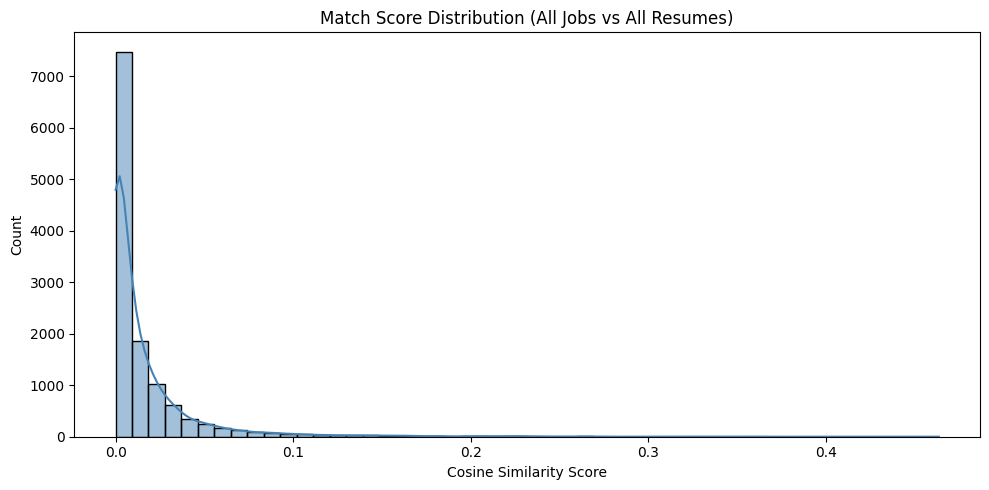

C:\Users\DELL\AppData\Local\Temp\ipykernel_58716\2621432596.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=results_df, x='experience_level', y='match_score', palette='Set2')


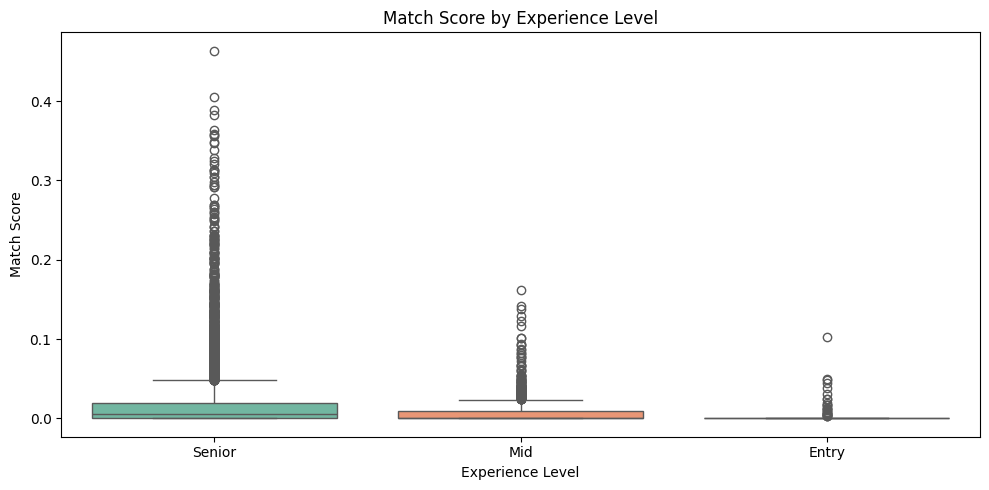

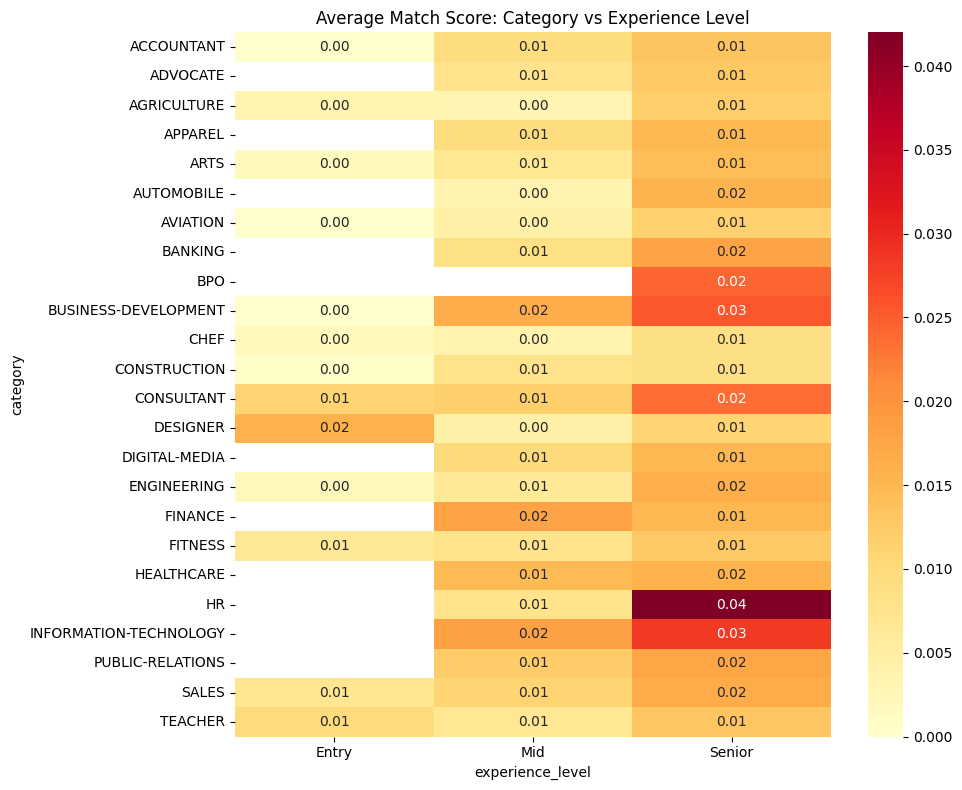

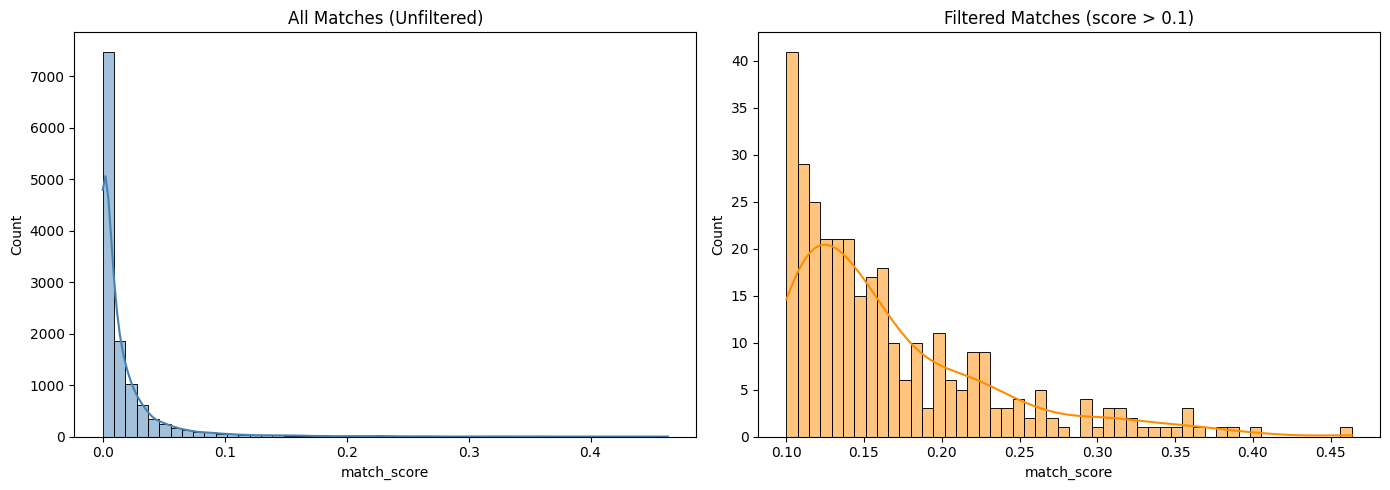

✅ All matching plots saved!


In [5]:
# ── Cell 6: Filter top matches (score > 0.1) ─────────────────────────────────
filtered_df = results_df[results_df['match_score'] > 0.1].copy()
filtered_df = filtered_df.sort_values('match_score', ascending=False)
filtered_df.to_csv("../results/metrics/filtered_matches.csv", index=False)
print(f"✅ Filtered matches saved → results/metrics/filtered_matches.csv")
print(f"   Filtered rows: {len(filtered_df)}")

# ── Cell 7: Match score distribution ─────────────────────────────────────────
plt.figure(figsize=(10, 5))
sns.histplot(results_df['match_score'], bins=50, color='steelblue', kde=True)
plt.title('Match Score Distribution (All Jobs vs All Resumes)')
plt.xlabel('Cosine Similarity Score')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("../results/plots/match_score_distribution.png", dpi=150)
plt.show()

# ── Cell 8: Match score by experience level ───────────────────────────────────
plt.figure(figsize=(10, 5))
sns.boxplot(data=results_df, x='experience_level', y='match_score', palette='Set2')
plt.title('Match Score by Experience Level')
plt.xlabel('Experience Level')
plt.ylabel('Match Score')
plt.tight_layout()
plt.savefig("../results/plots/match_score_by_experience.png", dpi=150)
plt.show()

# ── Cell 9: Heatmap — category vs experience ──────────────────────────────────
pivot = results_df.groupby(['category','experience_level'])['match_score'].mean().unstack()
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd')
plt.title('Average Match Score: Category vs Experience Level')
plt.tight_layout()
plt.savefig("../results/plots/match_heatmap_category_experience.png", dpi=150)
plt.show()

# ── Cell 10: Filtered vs unfiltered comparison ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(results_df['match_score'],  bins=50, ax=axes[0], color='steelblue', kde=True)
axes[0].set_title('All Matches (Unfiltered)')
sns.histplot(filtered_df['match_score'], bins=50, ax=axes[1], color='darkorange', kde=True)
axes[1].set_title('Filtered Matches (score > 0.1)')
plt.tight_layout()
plt.savefig("../results/plots/filtered_vs_unfiltered_scores.png", dpi=150)
plt.show()
print("✅ All matching plots saved!")